Data Exploration & Risk Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = "../data/raw/german_credit.data"

column_names = [
    "checking_account_status",
    "loan_duration_months",
    "credit_history",
    "loan_purpose",
    "credit_amount",
    "savings_account",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

df = pd.read_csv(
    data_path,
    sep=" ",
    header=None,
    names=column_names
)

In [3]:
df.shape

(1000, 21)

In [4]:
df.head()

,checking_account_status,loan_duration_months,credit_history,loan_purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  1000 non-null   object
 1   loan_duration_months     1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   loan_purpose             1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_duration       1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [6]:
df["credit_risk"].value_counts()

credit_risk
1    700
2    300
Name: count, dtype: int64

In [7]:
df["credit_risk"].value_counts(normalize=True) * 100

credit_risk
1    70.0
2    30.0
Name: proportion, dtype: float64

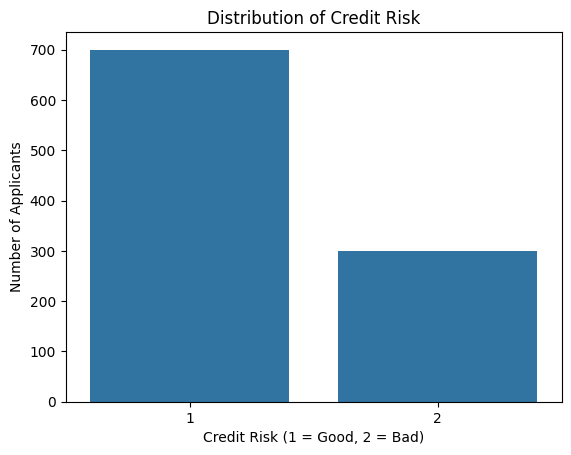

In [8]:
sns.countplot(x="credit_risk", data=df)
plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk (1 = Good, 2 = Bad)")
plt.ylabel("Number of Applicants")
plt.show()

In [9]:
df.describe()

,loan_duration_months,credit_amount,installment_rate,residence_duration,age,existing_credits,num_dependents,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


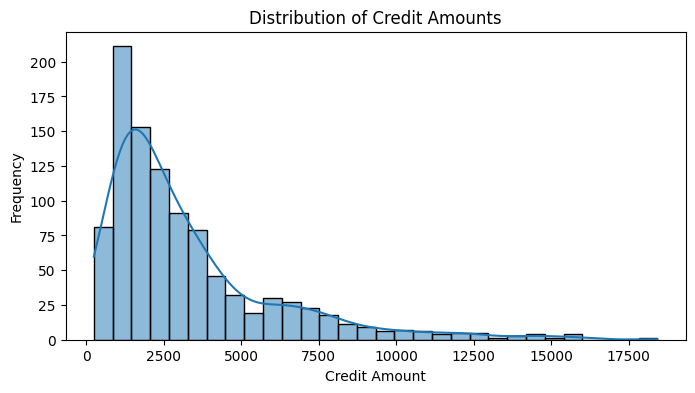

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df["credit_amount"], bins=30, kde=True)
plt.title("Distribution of Credit Amounts")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

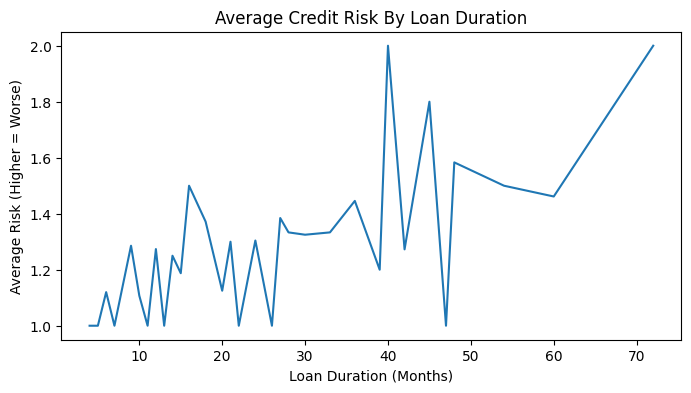

In [11]:
risk_by_duration = df.groupby("loan_duration_months")["credit_risk"].mean()

plt.figure(figsize=(8, 4))
risk_by_duration.plot()
plt.title("Average Credit Risk By Loan Duration")
plt.xlabel("Loan Duration (Months)")
plt.ylabel("Average Risk (Higher = Worse)")
plt.show()

## Bias and Ethical Risk — Initial Observations

Several variables in this dataset may introduce ethical or fairness risks:

- **Age** may correlate with financial stability but can disadvantage younger applicants.
- **Employment duration** may act as a proxy for socioeconomic status.
- **Housing status** can reflect structural inequality rather than creditworthiness.
- **Foreign worker** status introduces direct discrimination risk if misused.

These features may improve predictive performance but require careful handling,
human oversight, and explainability.
